# Task 1 — Train Three Logistic Regression Models

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [7]:
# Load the preprocessed dataset.
df = pd.read_csv("Telco_Customer_Churn_Preprocessed")

# Split features and target.
X = df.drop("Churn", axis=1)

# Store the target column.
y = df["Churn"]

# Split the dataset.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create the scaler.
scaler = StandardScaler()

# Fit the scaler on the training data.
X_train = scaler.fit_transform(X_train)

# Transform the test data.
X_test = scaler.transform(X_test)

# Train the model without regularization.
model_a = LogisticRegression(
    penalty=None,
    max_iter=1000
)

# Fit the model.
model_a.fit(X_train, y_train)

# Train the L1 regularized model.
model_b = LogisticRegression(
    penalty="l1",
    solver="saga",
    C=1.0,
    max_iter=1000
)

# Fit the model.
model_b.fit(X_train, y_train)

# Train the L2 regularized model.
model_c = LogisticRegression(
    penalty="l2",
    C=1.0,
    max_iter=1000
)

# Fit the model.
model_c.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

# Task 2 — Compare Performance

In [8]:
# Create a function to evaluate a model.
def evaluate(model, X_test, y_test, name):

    # Predict class labels.
    y_pred = model.predict(X_test)

    # Predict probabilities.
    y_proba = model.predict_proba(X_test)[:, 1]

    # Return all evaluation metrics.
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba)
    }

# Evaluate all models.
results = [
    evaluate(model_a, X_test, y_test, "No Regularization"),
    evaluate(model_b, X_test, y_test, "L1 (Lasso)"),
    evaluate(model_c, X_test, y_test, "L2 (Ridge)")
]

# Create the comparison table.
results_df = pd.DataFrame(results)

# Display the results.
print(results_df.set_index("Model"))


                   Accuracy  Precision    Recall        F1       AUC
Model                                                               
No Regularization  0.792761   0.633117  0.521390  0.571848  0.834134
L1 (Lasso)         0.793471   0.635179  0.521390  0.572687  0.834191
L2 (Ridge)         0.792051   0.631922  0.518717  0.569750  0.834129


# Task 3 — Compare Coefficients

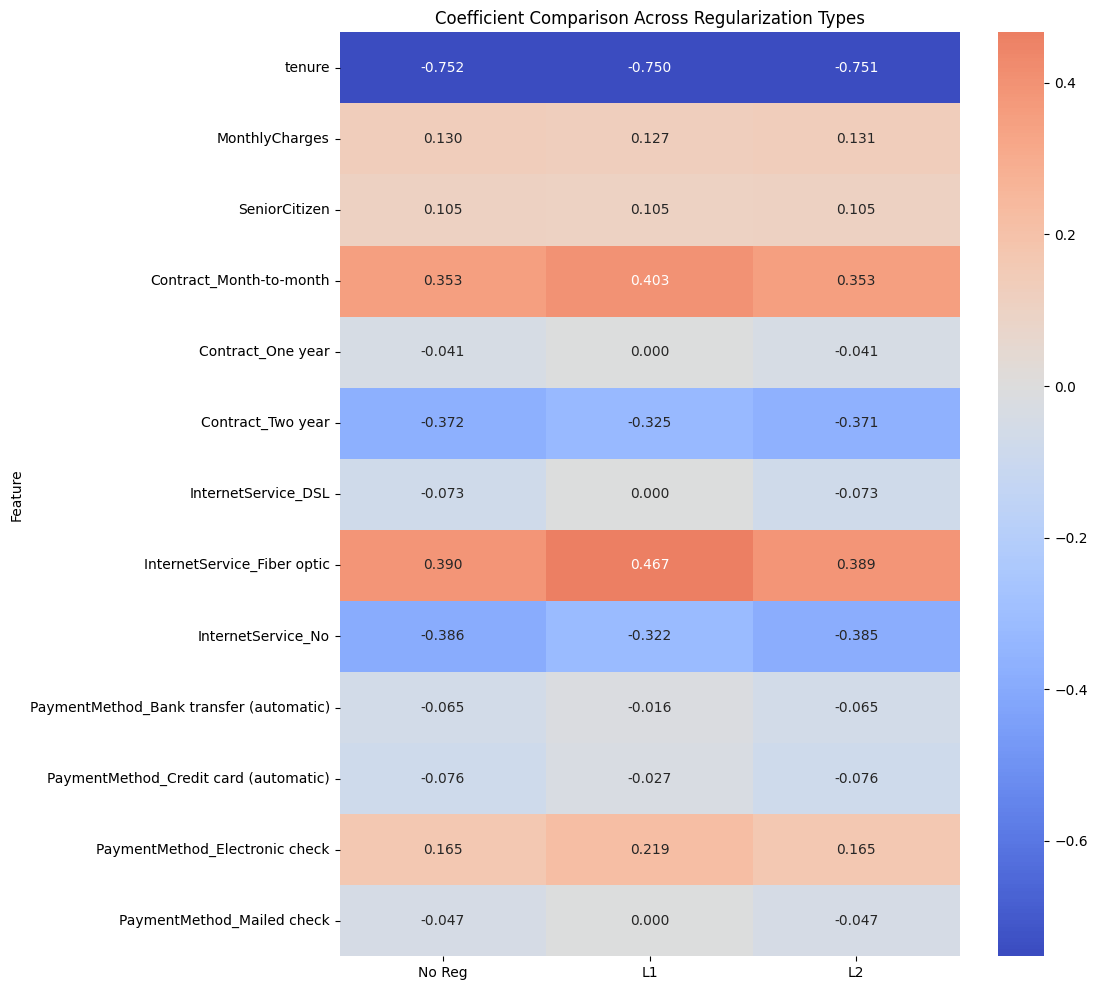

No Reg: 13 non-zero coefficients out of 13
L1: 10 non-zero coefficients out of 13
L2: 13 non-zero coefficients out of 13

Features set to zero by L1:
4              Contract_One year
6            InternetService_DSL
12    PaymentMethod_Mailed check
Name: Feature, dtype: object


In [9]:
# Create a dataframe with model coefficients.
coef_df = pd.DataFrame({
    "Feature": df.drop("Churn", axis=1).columns,
    "No Reg": model_a.coef_[0],
    "L1": model_b.coef_[0],
    "L2": model_c.coef_[0]
})

# Create the figure.
plt.figure(figsize=(10,12))

# Plot the heatmap.
sns.heatmap(
    coef_df.set_index("Feature"),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".3f"
)

# Add the title.
plt.title("Coefficient Comparison Across Regularization Types")

# Display the plot.
plt.show()

# Count non-zero coefficients.
for name, model in [
    ("No Reg", model_a),
    ("L1", model_b),
    ("L2", model_c)
]:

    # Count non-zero coefficients.
    n_nonzero = np.sum(model.coef_[0] != 0)

    # Print the result.
    print(f"{name}: {n_nonzero} non-zero coefficients out of {len(model.coef_[0])}")

# Find coefficients that L1 reduced to zero.
l1_zero = coef_df[coef_df["L1"] == 0]

# Display those features.
print("\nFeatures set to zero by L1:")
print(l1_zero["Feature"])

# Task 4 — Vary Regularization Strength

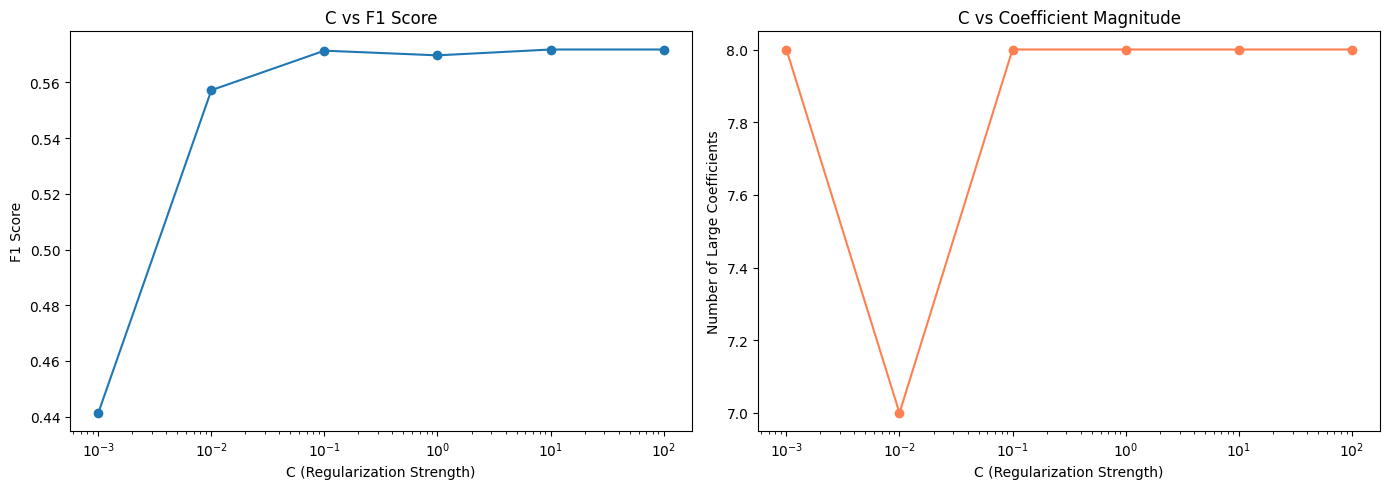

Best C value: 10


In [10]:
# Create the list of C values.
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

# Create a list for F1 scores.
f1_scores = []

# Create a list for large coefficients.
n_large_coefs = []

# Train models with different C values.
for C in C_values:

    # Create the model.
    model = LogisticRegression(
        penalty="l2",
        C=C,
        max_iter=1000
    )

    # Train the model.
    model.fit(X_train, y_train)

    # Predict the test labels.
    y_pred = model.predict(X_test)

    # Save the F1 score.
    f1_scores.append(f1_score(y_test, y_pred))

    # Count large coefficients.
    n_large_coefs.append(
        np.sum(np.abs(model.coef_[0]) > 0.1)
    )

# Create the figure.
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(14,5)
)

# Plot C versus F1.
ax1.plot(C_values, f1_scores, "o-")

# Use a logarithmic x-axis.
ax1.set_xscale("log")

# Label the x-axis.
ax1.set_xlabel("C (Regularization Strength)")

# Label the y-axis.
ax1.set_ylabel("F1 Score")

# Add the title.
ax1.set_title("C vs F1 Score")

# Plot C versus coefficient count.
ax2.plot(
    C_values,
    n_large_coefs,
    "o-",
    color="coral"
)

# Use a logarithmic x-axis.
ax2.set_xscale("log")

# Label the x-axis.
ax2.set_xlabel("C (Regularization Strength)")

# Label the y-axis.
ax2.set_ylabel("Number of Large Coefficients")

# Add the title.
ax2.set_title("C vs Coefficient Magnitude")

# Adjust the layout.
plt.tight_layout()

# Display the plots.
plt.show()

# Find the best C value.
best_C = C_values[np.argmax(f1_scores)]

# Print the result.
print(f"Best C value: {best_C}")